In [72]:
from cvxpy import *
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.signal import cont2discrete , tf2ss
import control as ct
import mplcursors

DEBUG_ = False
import cProfile

In [73]:
# if ():    
#     A = np.array([[1,0.5,-0.125], [0, 1 , -0.5],[0, 0, 1]])
#     B = np.array([[-0.0208], [-0.125], [0.5]])
#     dt = 0.5
#     A = np.array([[1,0.1,-0.005], [0, 1 , -0.1],[0, 0, 1]])
#     B = np.array([[-0.0001667], [-0.005], [0.1]])
#     dt = 0.1
#     A = np.array([[1,1,-0.5],[0,1,-1],[0,1,1]])
#     B = np.array([[-0.1667],[-0.5],[1]])
#     dt = 1
#     A = np.array([[1,0.05,-0.00125], [0, 1 , -0.05],[0, 0, 1]])
#     B = np.array([[-0], [-0.00125], [0.05]])
#     dt = 0.05

#     T_eng = 0.460
#     K_eng = 0.732
#     A_f = -1/T_eng
#     B_f = -K_eng/T_eng
#     C = np.eye(3)
#     T_hw = 1.6
#     Ts = 0.05
#     T_total = 10
#     T = int(T_total/Ts)
#     v0 = 15           # Initial target velocity
#     init_dist = 5     # Initial distance between vehicles

#     # Discretize the system
#     A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
#     B = np.array([[0], [0], [B_f]])
#     sys2   = cont2discrete((A, B, np.eye(3), 0), Ts, method='zoh')
#     A, B, C, D , dt = sys2

#     A = np.eye(3) + Ts*A
#     B = Ts*B
#     C = C_f 

In [74]:
def cvxpy_reverse(A, B, N, Q, R, P, x0, xr, umax=None, umin=None, xmin=None, xmax=None):
    is_sol =  False
    (nx, nu) = B.shape

    # mpc calculation  x0 = distance, x1 = velocity, x2 = accel 
    plt.scatter(xr[0], xr[1], marker='D', color='red', label='reference')
    x = cvxpy.Variable((nx, N + 1))
    u = cvxpy.Variable((nu, N))
    weights = np.ones(5)
    w1 = weights[0]*15
    w2 = weights[1]*2
    w0 = weights[2]*10
    w3 = weights[3]*3
    w4 = weights[4]*100

    costlist = 0.0
    constraints = []

    for t in range(N):
        costlist +=  (w1*((x[1, t]-xr[1])/10) + w2*(x[2, t]-xr[2]) + w0*((x[0, t]-xr[0])/100)) #cvxpy.quad_form(x[:, t]- xr, Q) #
        costlist += w3*u[:, t] #cvxpy.quad_form(u[:, t], R) #

        constraints += [x[:, t + 1] == A * x[:, t] + B * u[:, t]]

        if xmin is not None:
            constraints += [x[0, t] >= xmin[0, 0]]  # state is greater than x min 
            constraints += [x[2, t] >= xmin[1, 0]] # state is greater than x min 
        if xmax is not None:
            constraints += [x[2, t] <= xmax[0]] # state is less than x max 

    # costlist += 0.5 *((x[1, N]-xr[1]) + (x[2, N]-xr[2]) + (x[0, N]-xr[0])) # terminal cost #0.5 *((x[1, N]-xr[1])**2 + (x[2, N]-xr[2])**2 + (x[0, N]-xr[0])**2)  # terminal cost
    costlist += w4*((x[1, N]-xr[1]) + (x[2, N]-xr[2]) + (x[0, N]-xr[0]))
    if xmin is not None:
        constraints += [x[0, t] >= xmin[0, 0]]  # state is greater than x min 
        constraints += [x[2, t] >= xmin[1, 0]]
    if xmax is not None:
        constraints += [x[2, t] <= xmax[0]]

    if umax is not None:
        constraints += [u <= umax]  # input constraints
    if umin is not None:
        constraints += [u >= umin]  # input constraints

    # print("this is inside functio",x0)
    constraints += [x[:, 0] == x0]  # inital state constraints

    prob = cvxpy.Problem(cvxpy.Minimize(costlist), constraints)

    prob.solve(solver=ECOS , warm_start=True) #solver= OSQP,
    if prob.status == 'optimal':
        is_sol = True
    
    return is_sol , x.value, u.value, costlist.value

In [75]:

def cvxpy_reverse1(A, B, N, Q, R, P, x0, xr, umax=None, umin=None, xmin=None, xmax=None):  
    is_sol =  False
    (nx, nu) = B.shape

    # mpc calculation  x0 = distance, x1 = velocity, x2 = accel 
    x = cvxpy.Variable((nx, N + 1))
    u = cvxpy.Variable((nu, N))
    weights = np.ones(5)
    w0 = weights[0]*15
    w1 = weights[1]*15
    w2 = weights[2]*3
    w3 = weights[3]*20
    w4 = weights[4]*0
    R = np.eye(nu)

    costlist = 0.0
    constraints = []

    for t in range(N):
        # costlist +=  cvxpy.quad_form(x[:, t] - xr[1], Q)
        costlist +=  (w1*((x[1, t]-xr[1])) + w2*(x[2, t]-xr[2]) + w0*((x[0, t]-xr[0]))) #cvxpy.quad_form(x[:, t]- xr, Q) #
        # costlist += cvxpy.quad_form(u[:, t], R)
        costlist += w3*u[:, t]

        constraints += [x[:, t + 1] == A * x[:, t] + B * u[:, t]]

        if xmin is not None:
            constraints += [x[0, t] >= xmin[0, 0]]  # state is greater than x min 
            constraints += [x[2, t] >= xmin[1, 0]]
        if xmax is not None:
            constraints += [x[2, t] <= xmax[0]] # state is less than x max 

    # costlist += 0.5 *((x[1, N]-xr[1]) + (x[2, N]-xr[2]) + (x[0, N]-xr[0])) # terminal cost #0.5 *((x[1, N]-xr[1])**2 + (x[2, N]-xr[2])**2 + (x[0, N]-xr[0])**2)  # terminal cost
    costlist += w4 *((x[1, N]-xr[1]) + (x[2, N]-xr[2])**2 + (x[0, N]-xr[0]))
    # costlist +=  cvxpy.quad_form(x[:, N] - xr[1], P)
    if xmin is not None:
        constraints += [x[0, t] >= xmin[0, 0]]  # state is greater than x min 
        constraints += [x[2, t] >= xmin[1, 0]]
    if xmax is not None:
        constraints += [x[2, t] <= xmax[0]] # state is less than x max 

    if umax is not None:
        constraints += [u <= umax]  # input constraints
    if umin is not None:
        constraints += [u >= umin]  # input constraints

    ur1_max = 2
    ur1_min = -2
    # add input rate constraints
    # rate of change of u1 constraint
    for i in range(N-1):
        constraints += [u[0,i+1] - u[0,i] <= ur1_max]
        constraints += [u[0,i+1] - u[0,i] >= ur1_min]

    # print("this is inside functio",x0)
    constraints += [x[:, 0] == x0]  # inital state constraints

    prob = cvxpy.Problem(cvxpy.Minimize(costlist), constraints)

    prob.solve(solver=ECOS , warm_start=True) #solver= OSQP,
        
    if prob.status == 'optimal':
    # Problem was solved successfully
        is_sol = True
        print("Optimal solution found!")
    elif prob.status == 'infeasible':
        # Problem is infeasible (no feasible solution exists)
        print("Problem is infeasible.")
    elif prob.status == 'unbounded':
        # Problem is unbounded (no finite optimal solution exists)
        print("Problem is unbounded.")
    else:
        # Solver failed or terminated prematurely
        print("Solver failed or terminated prematurely. Status:", prob.status)
    
    return is_sol , x.value, u.value, costlist.value

In [76]:
def plotting(x_hist,u_hist,cost_hist,Xh,Xr,host_d, DEBUG_=True):
    
    if DEBUG_:
        u_hist = np.array(u_hist).squeeze()
        cost_hist = np.array(cost_hist)

        # Plot the responses and cost
        plt.figure(figsize=(16, 16))    
        plt.subplot(3, 1, 1)
        plt.plot(x_hist[:, 0], label='Dist', linewidth=2.5)
        plt.plot(-x_hist[:, 1], label='Velocity', linewidth=2.5)

        plt.legend()
        plt.title('MPC Response', fontsize=20)
        plt.ylabel('Distance and velocity', fontsize=16)
        plt.xlabel('Time', fontsize=16)
        plt.grid()

        plt.subplot(3, 1, 2)
        plt.plot(u_hist, label='u')
        plt.legend()
        plt.ylabel('Input')
        plt.grid()

        plt.subplot(3, 1, 3)
        plt.plot(cost_hist, label=' Cost')
        plt.legend()
        plt.xlabel('Time')
        plt.ylabel('Cost')
        plt.grid()
        
        # plt.subplot(4, 1, 4)
        # plt.plot(x_hist[:,2], label='Host accel')
        # # plt.plot(Xr, label='refernce distance')
        # plt.legend()
        # plt.ylabel('distance')
        # plt.grid()

        plt.figure(figsize=(8, 8))
        plt.subplot(3, 1, 1)
        plt.plot(host_d, label='difference in distance')
        plt.legend()
        plt.ylabel('meters')
        plt.grid()

        plt.subplot(3, 1, 2)
        plt.plot(x_hist[:, 2], label='accel')
        plt.legend()
        plt.ylabel('accel')
        plt.grid()
        plt.show()

In [77]:
def reference(T_total, Ts, init_dist, v0):  # Generate reference trajectory
# if __name__ == "__main__":
#     
    T_total = 30
#     Ts = 0.1
#     init_dist = 6
#     v0 = 0
    a = 1.5; # acceleration
    b = -2.5; # deceleration
    T1 = int(2/Ts)
    T2 = int(12/Ts)
    T3 = int(17/Ts)
    T4 = int(24/Ts)
    T =  int(T_total/Ts)

    x_current = np.zeros((T, 3)) # distance and velocity refernce is given 
    
    x_current[0, 0] = init_dist; 
    x_current[0, 1] = v0; 
    x_current[:, 2] = 0; 

    for k in range(1,T1 ):
        x_current[k, 0] = x_current[k-1, 0] + x_current[k-1, 1]*Ts; 
        x_current[k, 1] = 0; 
    
    for k in range(T1 ,T2 ):
        x_current[k, 0] = x_current[k-1, 0] + x_current[k-1, 1]*Ts + (0.5*a)*Ts**2; 
        x_current[k, 1] = x_current[k-1, 1] + a*Ts; 

    for k in range(T2 ,T3 ):
        x_current[k, 0] = x_current[k-1, 0] + x_current[k-1,1]*Ts; 
        x_current[k, 1] = x_current[k-1, 1]; 

    for k in range(T3 ,T4 ):
        x_current[k, 0] = x_current[k-1, 0] + x_current[k-1, 1]*Ts + (0.5*b)*Ts**2; 
        x_current[k, 1] = x_current[k-1, 1] + b*Ts; 

    for k in range(T4 ,T ):
        x_current[k, 0] = x_current[k-1, 0] + x_current[k,1]*Ts; 
        x_current[k, 1] = x_current[k-1, 1]; 
    
    
    y = np.arange(0, T_total, Ts)
    plt.plot(y , x_current[:,0], label='reference distance', linewidth=2.5)
    plt.plot(y , x_current[:,1], label='reference velocity', linewidth=2.5)
    plt.xlabel('time')
    plt.legend()
    plt.ylabel('distance')
    plt.grid()
    plt.show()
    
    return x_current

In [78]:
def reverse():
    print("start!! reverse ")
    T_eng = 0.460
    K_eng = 0.732
    A_f = -1/T_eng
    B_f = -K_eng/T_eng
    C = np.eye(3)
    T_hw = 1.6
    Ts = 0.1
    T_total = 30
    T = int(T_total/Ts)


    # Discretize the system
    A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
    B = np.array([[0], [0], [B_f]])
    sys2 = cont2discrete((A, B, np.eye(3), 0), Ts, method='zoh')
    A, B, C, D , dt = sys2

    (nx, nu) = B.shape

    Q = np.array([[1 , 0, 0],[0,0,0],[0,0,0]])
    R = np.eye(nu)*0
    P = np.eye(nx)*0

    ## x represents states 

    umax = 3
    umin = -3.5

    xmin = np.array([[0] ,[-2.5]])  # state constraints
    xmax = np.array([3])  # state constraints

    x0 = np.array([15, 0.0, 0])  # initial state
    # xr = np.array([0, 0 , 0]) # referance state 
    ## reference rtajectory for evaluation 
    init_dist = x0[0] # initial distance between vehicles
    v0 = 0 # initial velocity of the reference vehicle
    x_current = reference(T_total, Ts, v0, init_dist) # reference trajectory
    
    N = 30  # horizon
    iter = T # number of iteration
    x_hist = [x0]
    u_hist = []
    cost_hist = []
    xh = x_current[0,0] - x0[0]  # initial position of the host
    vh = x_current[0,1] - x0[1]  # initial velocity of the host
    d0 = 2 # tailgating distance between vehicles
    host_d = np.zeros((iter, 1))
    
    for i in range(5):  #iter
        x_r = x_current[i, :] # is reference vehicle parameters
        d_ref = x_r[0] - (xh + T_hw*vh + d0) # reference del d
        v_ref = x_r[1] - vh # reference del v
        
        plt.scatter(i, vh, c='g', marker='*')
        xr = np.array([d_ref, v_ref, 0]) # referance state
        # if i%2 == 0:
        #     plt.scatter(i, xh, c='b', marker='o')
        # else:
        #     plt.scatter(i, xh, c='r', marker='o')
        notfail, x, u, c = cvxpy_reverse1(A, B, N, Q, R, P, x0, xr, umax = umax, umin = umin, xmin = xmin, xmax = xmax)
        print('reference is :', xr) #, 'Cost:', c, 'Input:', u[:,0])
        print("the current state is :", x0)
        if  notfail :
            x0 = A.dot(x[:,0]) + B.dot(u[:,0]) #+ np.random.multivariate_normal(np.zeros(3), W)
            u_hist.append(u[:,0])
            print('Iteration:', i, 'Cost:', c, 'Input:', u[:,0])
            x_hist.append(x0)
            vh = x_r[1] - x0[1]
            xh = x_r[0] - (x0[0] + T_hw*vh + d0) 
            host_d[i] = xh
            cost_hist.append(c)
            print("this is car's states",xh,vh,x0[2])
        else:
             print('No solution',i)
             break
           
    x_hist = np.array(x_hist)
    u_hist = np.array(u_hist)
    cost_hist = np.array(cost_hist)
    # diff = x_current[0:iter+1,0] - x_hist[0:iter+1,0] 

    print("aa")
    plotting(x_hist,u_hist,cost_hist,host_d,x_current[:,0], host_d,True)
    
    return x_hist #cost_hist

start!! reverse 


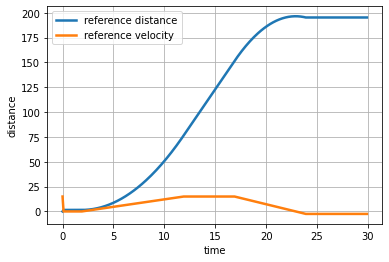

Optimal solution found!
reference is : [-11.   0.   0.]
the current state is : [15.  0.  0.]
Iteration: 0 Cost: [6271.76210388] Input: [-3.5]
Optimal solution found!
reference is : [ 16.45762417 -15.02593494   0.        ]
the current state is : [14.95762417 -0.02593494  0.50057622]
Iteration: 1 Cost: [583.34497943] Input: [-3.5]
Optimal solution found!
reference is : [14.83833937 -0.0968602   0.        ]
the current state is : [14.83833937 -0.0968602   0.90334739]
Iteration: 2 Cost: [-5509.49210635] Input: [-3.5]
Optimal solution found!
reference is : [14.65216669 -0.20398536  0.        ]
the current state is : [14.65216669 -0.20398536  1.22742313]
Iteration: 3 Cost: [-5487.28645701] Input: [-3.5]
Optimal solution found!
reference is : [14.40716925 -0.3402375   0.        ]
the current state is : [14.40716925 -0.3402375   1.48817935]
Iteration: 4 Cost: [-5428.67665608] Input: [-3.5]
Optimal solution found!
reference is : [14.10983477 -0.49992564  0.        ]
the current state is : [14.1

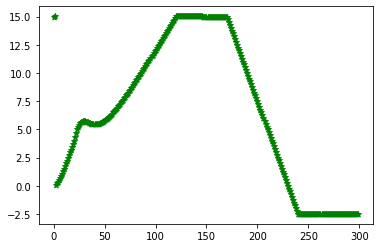

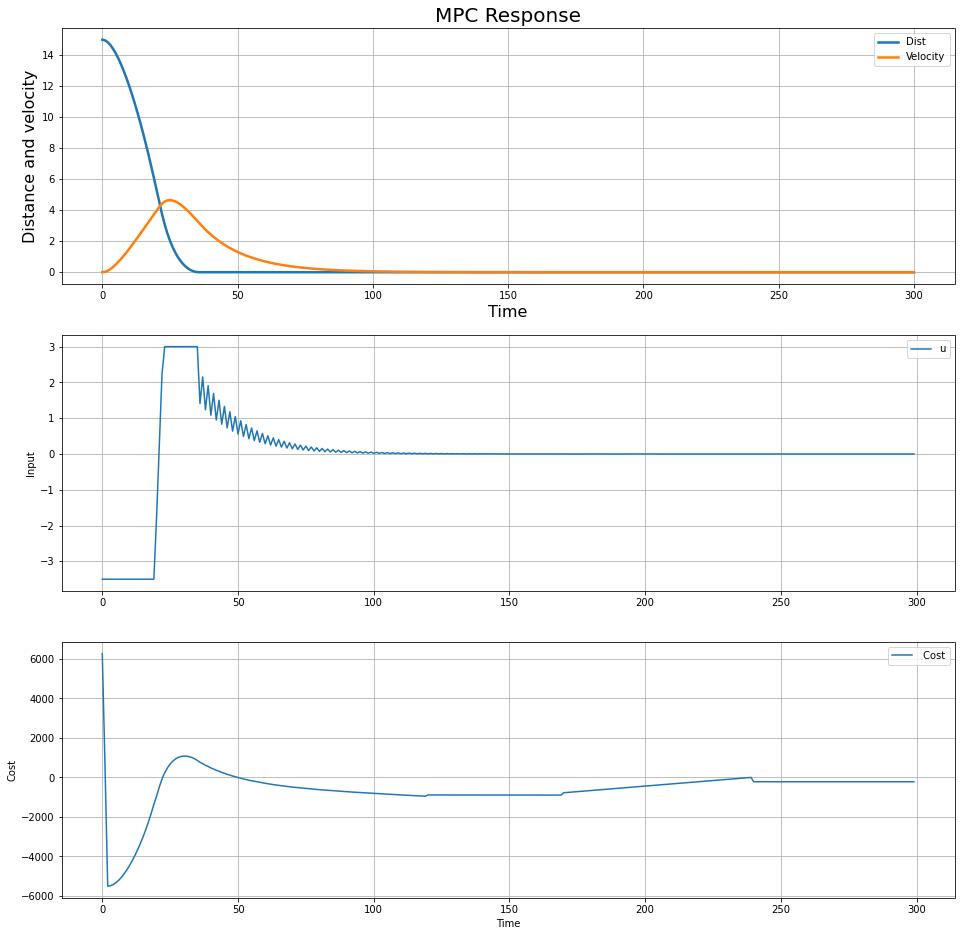

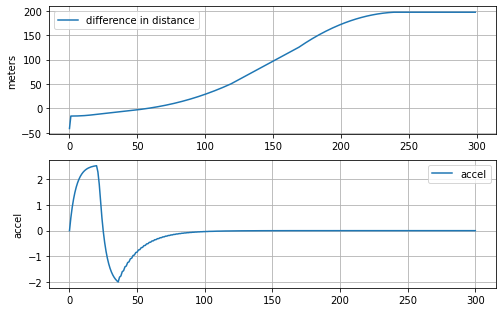

In [79]:
if __name__ == '__main__':
    DEBUG_ = False
    #x_rev = cProfile.run('reverse()')
    x_rev = reverse()
    # for k in range(1,len(x_rev[:,0])):
    # #print(x_rev[k,0])
    #     if 99 < x_rev[k,0] < 101:
    #         break
   
    # forward()

<Figure size 1152x1152 with 0 Axes>

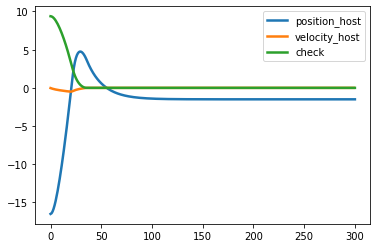

In [80]:
T_hw = 1.6
do = 1.5 #  distance gap between vehicles
dis = 0 - x_rev[:,0] - T_hw*x_rev[:,1] - 1.5
dis3 = x_rev[:,0]
dis2 = x_rev[:,0]/T_hw 
vh = dis2[1:] - dis2[:-1]

# print(dis[2:])
# velh = x_rev[:,1]
# dx = [0]
# d2x = [0]
# vel = [] 

# # for i in range(1,len(dis)):
# #    d2x.append(10 - dis[i] - T_hw*velh + do)
# #    velh = d2x[i] - d2x[i-1]
# #    vel.append(velh)


# dx = dis[2:] - dis[:-2]
# d2x = dis[2:] - 2*dis[1:-1] + dis[:-2]

plt.figure(figsize=(16, 16))   
fig, ax = plt.subplots()

ax.plot(dis, label='position_host', linewidth=2.5)
ax.plot(vh, label='velocity_host', linewidth=2.5)
ax.plot(dis2, label='check', linewidth=2.5)
# Create a cursor object and configure it to show the data values
# cursor = mplcursors.cursor(ax, hover=True)
# cursor.connect("add", lambda sel: sel.annotation.set_text(f'({sel.target[0]:.2f}, {sel.target[1]:.2f})'))

ax.legend()

In [81]:
def forward():
    print("start!! forward !!")
    A = np.array([[1,0.05,-0.00125], [0, 1 , -0.05],[0, 0, 1]])
    B = np.array([[-0], [-0.00125], [0.05]])
    #dt = 0.05
    (nx, nu) = B.shape
    
    # Q = np.array([[100 , 10, 10],[10,10,10],[10,10,10]])
    Q = np.array([[0.05 , 0, 0],[0,0.0075,0],[0,0,0.0075]])
    R = np.eye(nu)*0.5
    P = np.eye(nx)*0.1

    x0 = np.array([100.0, 16.0, 0]) # initial state
    umax = 0.4
    umin = -0.8

    xmin = np.array([[3], [-50], [-4.5]])  # state constraints
    xmax = np.array([[600], [50.0],[3.0]])  # state constraints

    x_current = x0
    N = 15  # number of horizon
    iter = 60
    x_hist = [x_current]
    u_hist = []
    cost_hist = []
    # run = min( (x_rev.size/3-15), iter - N )  
    # for i in range(int(x_rev.size/3) - N -1): #iter -N-2  
    #     xr = x_rev[i:i+N,:]
    #     is_sol, x, u, c = cvxpy_forward(A, B, N,R, x0, xr, umax=umax, umin=umin, xmin=xmin, xmax=xmax)
    #     # print('Iteration:', i) #, 'Cost:', c, 'Input:', u[:,0])
    #     if  is_sol :
    #         x0 = A.dot(x[:,0]) + B.dot(u[:,0])
    #         u_hist.append(u[:,0])
    #         x_hist.append(x0)
    #         cost_hist.append(c)
    #     else:
    #          print('No solution',i)
    #          break
    
    for i in range(iter):
        notfail, x, u, c = cvxpy_reverse(A, B, N, Q, R, P, x0, xr, umax, umin, xmin, xmax)
        # print('Iteration:', i) #, 'Cost:', c, 'Input:', u[:,0])
        if  notfail :
            x0 = A.dot(x[:,0]) + B.dot(u[:,0]) #+ np.random.multivariate_normal(np.zeros(3), W)
            u_hist.append(u[:,0])
            x_hist.append(x0)
            cost_hist.append(c)
        else:
             print('No solution',i)
             break

    print("aa")
    Xh = []
    # Xr = [int(xr[0,0])]
    xr = np.array([8.0, 0 , 0])
    diff = []
    Vr = 0
    x_hist = np.array(x_hist)
    for k in range(1,len(x_hist[:,0])):
        # Xr.append( Vr*0.5) #Xr[k-1] +
        Xh.append( x_hist[k,0]) #Xr[k] - 
        diff.append(-x_hist[k,0])

    plotting(x_hist,u_hist,cost_hist,Xh,xr,diff,True)  

In [82]:
def cvxpy_forward(A, B, N, R, x0, xr, umax=None, umin=None, xmin=None, xmax=None):
    f =  False
    (nx, nu) = B.shape

    # mpc calculation x0 = distance, x1 = velocity, x2 = accel  
    x = cvxpy.Variable((nx, N + 1))
    u = cvxpy.Variable((nu, N))
    w1 = 1
    w2 = 0.5
    w3 = 0.2

    costlist = 0.0
    constraints = []
    # print("this is size of xr" , xr.size)
    
    for t in range(N):
        costlist +=  (w3*((x[0, t])) + w2*(x[2, t]) +  w1*((x[1, t])) ) # -xr[t,2]
        costlist += 0.5*u[:, t] #0.05 * cvxpy.quad_form(u[:, t], R)

        constraints += [x[:, t + 1] == A * x[:, t] + B * u[:, t]]

        if xmin is not None:
            constraints += [x[:, t] >= xmin[:, 0]]
        if xmax is not None:
            constraints += [x[:, t] <= xmax[:, 0]]

    costlist +=  0.5 *((x[1, N]) + (x[2, N]) + (x[0, N])) #0.5* (((x[2, N]-xr[N,2])**2  + ((x[1, N]-xr[N,1]))**2))  # terminal cost ((x[0, t]- xr[t,0])/100)**2
    if xmin is not None:
        constraints += [x[:, N] >= xmin[:, 0]]
    if xmax is not None:
        constraints += [x[:, N] <= xmax[:, 0]]

    if umax is not None:
        constraints += [u <= umax]  # input constraints
    if umin is not None:
        constraints += [u >= umin]  # input constraints

    constraints += [x[:, 0] == x0]  # inital state constraints

    prob = cvxpy.Problem(cvxpy.Minimize(costlist), constraints)

    prob.solve(solver=ECOS , warm_start=True) #solver= OSQP,
    if prob.status == 'optimal':
        f = True
    
    return f , x.value, u.value, costlist.value